# CH-5 Decision Trees

In [46]:
import pandas as pd
df = pd.read_csv(".csv")
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,High,Good,High,Good,Yes
1,Medium,Good,High,Good,Yes
2,Low,Bad,Low,Good,No
3,Low,Good,Low,Bad,No
4,High,Good,High,Bad,Yes
5,High,Good,High,Good,Yes
6,Medium,Bad,Low,Bad,No
7,Medium,Bad,Low,Good,No
8,High,Bad,High,Good,Yes
9,Medium,Good,High,Good,Yes


In [47]:
x=df.iloc[:,0:4]
x=pd.get_dummies(x,drop_first=True)
y=df.iloc[:,-1]

from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="entropy",max_depth=4)
m=model.fit(x,y)
# model.get_depth() # to get the depth of tree


from sklearn import tree 
print(tree.export_text(model))


y_pred=model.predict(x)
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y,y_pred)
print(cm)
print("accuracy :",accuracy_score(y,y_pred)) # depends on depth



|--- feature_3 <= 0.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_0 <= 0.50
|   |   |   |--- feature_1 <= 0.50
|   |   |   |   |--- class: Yes
|   |   |   |--- feature_1 >  0.50
|   |   |   |   |--- class: No
|   |   |--- feature_0 >  0.50
|   |   |   |--- class: No
|   |--- feature_2 >  0.50
|   |   |--- class: Yes
|--- feature_3 >  0.50
|   |--- class: No

[[10  0]
 [ 0  8]]
accuracy : 1.0


In [50]:
# create a dicision tree model for diabetes.csv dataset display cm , accuracy score , error rate , specificity & sencitivity

import pandas as pd
df = pd.read_csv("diabetes.csv")
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [51]:
x=df.iloc[:,0:8]
y=df.iloc[:,-1]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="entropy",max_depth=13)
m=model.fit(x_train,y_train)
y_pred=model.predict(x_test)


from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm=confusion_matrix(y_test,y_pred)
print("confusion_matrix :",cm)
print("TP :",cm[1][1])
print("TN :",cm[0][0])
print("FN :",cm[1][0])
print("FP :",cm[0][1])
print("accuracy_score :",accuracy_score(y_test,y_pred))
print("classification_report \n:",classification_report(y_test,y_pred))




confusion_matrix : [[78 17]
 [24 35]]
TP : 35
TN : 78
FN : 24
FP : 17
accuracy_score : 0.7337662337662337
classification_report 
:               precision    recall  f1-score   support

           0       0.76      0.82      0.79        95
           1       0.67      0.59      0.63        59

    accuracy                           0.73       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



In [40]:
import pandas as pd
df = pd.read_csv("data_breast_cancer.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [41]:
x=df.iloc[:,2:]
y=df.iloc[:,1]
y=pd.get_dummies(y,drop_first=True)


confusion_matrix : [[68  7]
 [ 5 34]]
TP : 34
TN : 68
FN : 5
FP : 7
accuracy_score : 0.8947368421052632
classification_report 
:               precision    recall  f1-score   support

       False       0.93      0.91      0.92        75
        True       0.83      0.87      0.85        39

    accuracy                           0.89       114
   macro avg       0.88      0.89      0.88       114
weighted avg       0.90      0.89      0.90       114



[Text(0.5336538461538461, 0.9285714285714286, 'x[22] <= 102.4\nentropy = 0.958\nsamples = 455\nvalue = [282, 173]'),
 Text(0.28846153846153844, 0.7857142857142857, 'x[27] <= 0.181\nentropy = 0.18\nsamples = 257\nvalue = [250, 7]'),
 Text(0.4110576923076923, 0.8571428571428572, 'True  '),
 Text(0.25, 0.6428571428571429, 'x[3] <= 657.85\nentropy = 0.117\nsamples = 254\nvalue = [250, 4]'),
 Text(0.15384615384615385, 0.5, 'x[24] <= 0.191\nentropy = 0.067\nsamples = 250\nvalue = [248, 2]'),
 Text(0.07692307692307693, 0.35714285714285715, 'x[13] <= 47.035\nentropy = 0.038\nsamples = 248\nvalue = [247, 1]'),
 Text(0.038461538461538464, 0.21428571428571427, 'entropy = 0.0\nsamples = 244\nvalue = [244, 0]'),
 Text(0.11538461538461539, 0.21428571428571427, 'x[25] <= 0.085\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]'),
 Text(0.07692307692307693, 0.07142857142857142, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.15384615384615385, 0.07142857142857142, 'entropy = 0.0\nsamples = 3\nvalue 

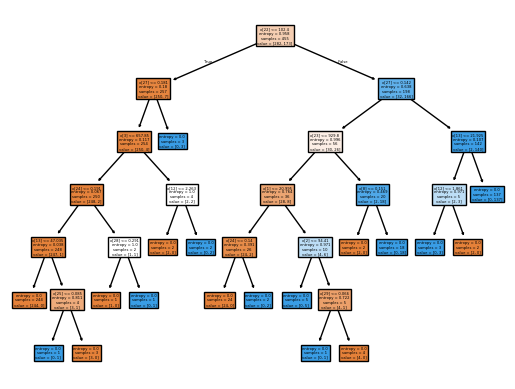

In [43]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="entropy",max_depth=15)
m=model.fit(x_train,y_train)
y_pred=model.predict(x_test)


from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm=confusion_matrix(y_test,y_pred)
print("confusion_matrix :",cm)
print("TP :",cm[1][1])
print("TN :",cm[0][0])
print("FN :",cm[1][0])
print("FP :",cm[0][1])
print("accuracy_score :",accuracy_score(y_test,y_pred))
print("classification_report \n:",classification_report(y_test,y_pred))

from sklearn.tree  import plot_tree
plot_tree(model,filled=True)

create a decision tree clasification model for fish.csv dataset confusion matrix, accuracy score , classification report

In [1]:
#step-1 : load dataset
import pandas as pd
df=pd.read_csv("fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [3]:
# step-2 :define x & y
x=df.iloc[:,1:]
y=df.iloc[:,0]


In [4]:
# step-3 : split the data in train and test , test_size=0.2 , random_state=42

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
# step-4 : import model

# from sklearn.tree import DecisionTreeClassifier
# model=DecisionTreeClassifier(criterion="entropy",max_depth=15)

from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=13)

In [6]:
#step-5 : fit or traim model , det depth of tree
m=model.fit(x_train,y_train)
# print(model.get_depth())

In [7]:
#step-6 : predict y for x_test
y_pred=model.predict(x_test)

In [8]:
#step-7 : 

from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm=confusion_matrix(y_test,y_pred)
print("confusion_matrix :",cm)
print("TP :",cm[1][1])
print("TN :",cm[0][0])
print("FN :",cm[1][0])
print("FP :",cm[0][1])
print("accuracy_score :",accuracy_score(y_test,y_pred))
print("classification_report :",classification_report(y_test,y_pred))

confusion_matrix : [[7 0 3 0 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 6 0 3 0 0]
 [1 0 1 0 1 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 5 0]
 [0 0 3 0 0 0 0]]
TP : 0
TN : 7
FN : 0
FP : 0
accuracy_score : 0.59375
classification_report :               precision    recall  f1-score   support

       Bream       0.88      0.70      0.78        10
      Parkki       0.00      0.00      0.00         1
       Perch       0.46      0.67      0.55         9
        Pike       0.00      0.00      0.00         3
       Roach       0.17      1.00      0.29         1
       Smelt       1.00      1.00      1.00         5
   Whitefish       0.00      0.00      0.00         3

    accuracy                           0.59        32
   macro avg       0.36      0.48      0.37        32
weighted avg       0.56      0.59      0.56        32



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Rendom Forest Classifier 

In [13]:
import pandas as pd
df=pd.read_csv("fish.csv")
x=df.iloc[:,1:]
y=df.iloc[:,0]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10)
m=model.fit(x_train,y_train)
y_pred=model.predict(x_test)

from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm=confusion_matrix(y_test,y_pred)
print("confusion_matrix :",cm)
print("TP :",cm[1][1])
print("TN :",cm[0][0])
print("FN :",cm[1][0])
print("FP :",cm[0][1])
print("accuracy_score :",accuracy_score(y_test,y_pred))
print("classification_report :",classification_report(y_test,y_pred))

confusion_matrix : [[10  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0]
 [ 0  0  6  0  3  0  0]
 [ 0  0  0  3  0  0  0]
 [ 0  0  1  0  0  0  0]
 [ 0  0  0  0  0  5  0]
 [ 0  0  1  0  2  0  0]]
TP : 1
TN : 10
FN : 0
FP : 0
accuracy_score : 0.78125
classification_report :               precision    recall  f1-score   support

       Bream       1.00      1.00      1.00        10
      Parkki       1.00      1.00      1.00         1
       Perch       0.75      0.67      0.71         9
        Pike       1.00      1.00      1.00         3
       Roach       0.00      0.00      0.00         1
       Smelt       1.00      1.00      1.00         5
   Whitefish       0.00      0.00      0.00         3

    accuracy                           0.78        32
   macro avg       0.68      0.67      0.67        32
weighted avg       0.80      0.78      0.79        32



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


 Create model of Random Forest Classifier for iris.csv

In [15]:
import pandas as pd
df=pd.read_csv("iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [16]:
x=df.iloc[:,1:5]
y=df.iloc[:,-1]

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [18]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10)
m=model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [19]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm=confusion_matrix(y_test,y_pred)
print("confusion_matrix :",cm)
print("TP :",cm[1][1])
print("TN :",cm[0][0])
print("FN :",cm[1][0])
print("FP :",cm[0][1])
print("accuracy_score :",accuracy_score(y_test,y_pred))
print("classification_report :",classification_report(y_test,y_pred))

confusion_matrix : [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
TP : 9
TN : 10
FN : 0
FP : 0
accuracy_score : 1.0
classification_report :                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# 227

Write a program to create a Model using linear regression to predict the charges of insurance using the csv file provided named 
“insurance.csv”. Do the required process in the data before making a model. Find predicted values, co-efficients, intercept and 
mean squared error.

In [20]:
import pandas as pd
df=pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [22]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [34]:
x=df.iloc[:,0:6]
y=df.iloc[:,-1]
x=pd.get_dummies(x,drop_first=True)

In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

In [36]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
m=lr.fit(x_train,y_train)
y_pred=(lr.predict(x_test))

In [37]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("mae :",mean_absolute_error(y_test,y_pred))
print("sqr :",mean_squared_error(y_test,y_pred))
print("r2Score :",r2_score(y_test,y_pred))

mae : 4358.280567455452
sqr : 39737837.0602452
r2Score : 0.7341854344194202


In [39]:
print("coefficient: ",lr.coef_)

coefficient:  [  254.74380593   326.37904839   583.2708384   -109.93652974
 23771.28324974  -489.59893571  -797.9625649   -859.27596641]


In [41]:
print("intercept: ",lr.intercept_)

intercept:  -11662.031402688337


# SVM - (Support Vector Machine)

In [1]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
x=df.iloc[:,0:8]
y=df.iloc[:,-1]


In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

In [6]:
from sklearn.svm import SVC
svc_model=SVC(kernel="rbf",random_state=42,C=10) # kernel="rbf" by default 
# C in regulization parameter high value of C will increase margin distance and reduce error it may go in overfitting 
# low value of  C will decrease marginal distance and reduce accuray
# kernal will convert dataset from higher dimension to make it saperable
# rbf radial bias function , most powerfull and commonly

svc_model.fit(x_train,y_train)
y_pred=svc_model.predict(x_test)


In [7]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm=confusion_matrix(y_test,y_pred)
print("confusion_matrix :",cm)
print("TP :",cm[1][1])
print("TN :",cm[0][0])
print("FN :",cm[1][0])
print("FP :",cm[0][1])
print("accuracy_score :",accuracy_score(y_test,y_pred))
print("classification_report :",classification_report(y_test,y_pred))

confusion_matrix : [[84 11]
 [28 31]]
TP : 31
TN : 84
FN : 28
FP : 11
accuracy_score : 0.7467532467532467
classification_report :               precision    recall  f1-score   support

           0       0.75      0.88      0.81        95
           1       0.74      0.53      0.61        59

    accuracy                           0.75       154
   macro avg       0.74      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



In [8]:
import pandas as pd
df=pd.read_csv("Employee_Attrition.csv")
df

,Employee_ID,Age,Monthly_Income,Years_at_Company,Job_Role,Work_Life_Balance,Overtime,Job_Satisfaction,Distance_From_Home,Education,Attrition
0,1,29,23278,8,Manager,Poor,Yes,1,22,Postgraduate,1
1,2,56,31395,18,HR,Poor,Yes,1,7,School,1
2,3,54,98907,0,Manager,Excellent,No,2,15,Postgraduate,0
3,4,39,20851,5,HR,Good,No,2,7,Graduate,0
4,5,28,32156,12,Developer,Good,No,3,26,School,0
...,...,...,...,...,...,...,...,...,...,...,...
245,246,46,39369,7,Developer,Excellent,Yes,2,1,Graduate,0
246,247,42,74890,4,HR,Excellent,Yes,4,17,Postgraduate,0
247,248,52,116447,1,Manager,Excellent,Yes,3,22,Graduate,0
248,249,55,69391,10,Manager,Good,No,3,22,Postgraduate,0


In [11]:
df.isna().sum()

Employee_ID           0
Age                   0
Monthly_Income        0
Years_at_Company      0
Job_Role              0
Work_Life_Balance     0
Overtime              0
Job_Satisfaction      0
Distance_From_Home    0
Education             0
Attrition             0
dtype: int64

In [13]:
df=df.drop("Employee_ID",axis=1)
df


,Age,Monthly_Income,Years_at_Company,Job_Role,Work_Life_Balance,Overtime,Job_Satisfaction,Distance_From_Home,Education,Attrition
0,29,23278,8,Manager,Poor,Yes,1,22,Postgraduate,1
1,56,31395,18,HR,Poor,Yes,1,7,School,1
2,54,98907,0,Manager,Excellent,No,2,15,Postgraduate,0
3,39,20851,5,HR,Good,No,2,7,Graduate,0
4,28,32156,12,Developer,Good,No,3,26,School,0
...,...,...,...,...,...,...,...,...,...,...
245,46,39369,7,Developer,Excellent,Yes,2,1,Graduate,0
246,42,74890,4,HR,Excellent,Yes,4,17,Postgraduate,0
247,52,116447,1,Manager,Excellent,Yes,3,22,Graduate,0
248,55,69391,10,Manager,Good,No,3,22,Postgraduate,0


In [18]:
x=df.iloc[:,0:9]
y=df.iloc[:,-1]
x=pd.get_dummies(x,drop_first=True)

In [28]:
# knn

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

acc_list=[]
for k in range(1,26):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test) 
    acc=accuracy_score(y_test,y_pred)
    acc_list.append(acc)
    print(f"k={k},Accuracy ={acc}")
max_acc=max(acc_list)

best_k=(acc_list.index(max_acc))+1
print(best_k)  
   
knn=KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train,y_train)


from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=150,random_state=42,max_depth=12,criterion="entropy")
m=model.fit(x_train,y_train)
y_pred1=model.predict(x_test)
acc=accuracy_score(y_test,y_pred1)
print("Accuracy of RF :",acc)
cm=confusion_matrix(y_test,y_pred1)
print("confusion_matrix  for RF:",cm)

import numpy as np
x_t=np.array([30,45000,5,3,10,1,0,0,1,0,1,0,0]).reshape(1,-1)
print(x_t)
print("Prediction for knn model :",knn.predict(x_t))
print("Prediction for RF model :",model.predict(x_t))


k=1,Accuracy =0.86
k=2,Accuracy =0.94
k=3,Accuracy =0.94
k=4,Accuracy =0.94
k=5,Accuracy =0.94
k=6,Accuracy =0.94
k=7,Accuracy =0.94
k=8,Accuracy =0.94
k=9,Accuracy =0.94
k=10,Accuracy =0.94
k=11,Accuracy =0.94
k=12,Accuracy =0.94
k=13,Accuracy =0.94
k=14,Accuracy =0.94
k=15,Accuracy =0.94
k=16,Accuracy =0.94
k=17,Accuracy =0.94
k=18,Accuracy =0.94
k=19,Accuracy =0.94
k=20,Accuracy =0.94
k=21,Accuracy =0.94
k=22,Accuracy =0.94
k=23,Accuracy =0.94
k=24,Accuracy =0.94
k=25,Accuracy =0.94
2
Accuracy of RF : 0.98
confusion_matrix  for RF: [[47  0]
 [ 1  2]]
[[   30 45000     5     3    10     1     0     0     1     0     1     0
      0]]
Prediction for knn model : [0]
Prediction for RF model : [0]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [29]:
import pandas as pd
df=pd.read_csv("Employee_Attrition.csv")
df

,Employee_ID,Age,Monthly_Income,Years_at_Company,Job_Role,Work_Life_Balance,Overtime,Job_Satisfaction,Distance_From_Home,Education,Attrition
0,1,29,23278,8,Manager,Poor,Yes,1,22,Postgraduate,1
1,2,56,31395,18,HR,Poor,Yes,1,7,School,1
2,3,54,98907,0,Manager,Excellent,No,2,15,Postgraduate,0
3,4,39,20851,5,HR,Good,No,2,7,Graduate,0
4,5,28,32156,12,Developer,Good,No,3,26,School,0
...,...,...,...,...,...,...,...,...,...,...,...
245,246,46,39369,7,Developer,Excellent,Yes,2,1,Graduate,0
246,247,42,74890,4,HR,Excellent,Yes,4,17,Postgraduate,0
247,248,52,116447,1,Manager,Excellent,Yes,3,22,Graduate,0
248,249,55,69391,10,Manager,Good,No,3,22,Postgraduate,0


In [30]:
x=df.iloc[:,1:9]
y=df.iloc[:,-1]
x=pd.get_dummies(x,drop_first=True)

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
from sklearn.svm import SVC
svc_model=SVC(kernel="rbf",random_state=42,C=10)
svc_model.fit(x_train,y_train)
y_pred=svc_model.predict(x_test)

In [40]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm=confusion_matrix(y_test,y_pred)
print("confusion_matrix :",cm)
print("TP :",cm[1][1])
print("TN :",cm[0][0])
print("FN :",cm[1][0])
print("FP :",cm[0][1])
print("accuracy_score :",accuracy_score(y_test,y_pred))
print("classification_report :",classification_report(y_test,y_pred))

confusion_matrix : [[47  0]
 [ 3  0]]
TP : 0
TN : 47
FN : 3
FP : 0
accuracy_score : 0.94
classification_report :               precision    recall  f1-score   support

           0       0.94      1.00      0.97        47
           1       0.00      0.00      0.00         3

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
